In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os

In [39]:
# Cell 2: 设置参数
result_dir = '/data/qiaodan/code/diffmarl/results/nips/simple_tag/SEQ_random_beta0.5_critic499_seed42_2025-05-16_16-20-02-114278'
exp_id = 'pp'
plot_id = 'tsne'

# 设置保存路径
save_dir = os.path.join('/data/qiaodan/code/diffmarl/plots', plot_id)
os.makedirs(save_dir, exist_ok=True)

In [40]:
# Cell 3: 定义数据加载函数
def load_and_process_data(data_path):
    """加载数据并处理成适合t-SNE的格式"""
    data = np.load(data_path)
    
    all_states = []
    all_actions = []
    
    # data['obs']: [n_episodes, episode_len, n_predators, obs_dim]
    # data['actions']: [n_episodes, episode_len, n_predators, action_dim]
    for episode_obs, episode_actions in zip(data['obs'], data['actions']):
        for step_obs, step_actions in zip(episode_obs, episode_actions):
            # 拼接所有agent的状态和动作
            joint_state = np.concatenate([obs.flatten() for obs in step_obs])
            joint_action = np.concatenate([act.flatten() for act in step_actions])
            
            all_states.append(joint_state)
            all_actions.append(joint_action)
    
    return np.array(all_states), np.array(all_actions)


In [41]:
# Cell 6: 加载原始数据集
dataset_dir = '/data/qiaodan/code/diffmarl/datasets/simple_tag/random/seed_0_data'

def load_dataset(dataset_dir, n_agents=3):
    """加载训练数据集"""
    all_states = []
    all_actions = []
    
    # 加载每个智能体的数据
    obs_data = [np.load(os.path.join(dataset_dir, f'obs_{i}.npy')) for i in range(n_agents)]
    acs_data = [np.load(os.path.join(dataset_dir, f'acs_{i}.npy')) for i in range(n_agents)]
    
    # obs_data[i].shape: [n_transitions, obs_dim]
    n_transitions = obs_data[0].shape[0]
    
    # 对每个时间步
    for step in range(n_transitions):
        # 拼接所有智能体的观测和动作
        joint_state = np.concatenate([obs_data[i][step].flatten() for i in range(n_agents)])
        joint_action = np.concatenate([acs_data[i][step].flatten() for i in range(n_agents)])
        
        all_states.append(joint_state)
        all_actions.append(joint_action)
    
    return np.array(all_states), np.array(all_actions)

print(f"\n加载训练数据集...")
dataset_states, dataset_actions = load_dataset(dataset_dir)
print(f"训练数据集 - 状态维度: {dataset_states.shape}, 动作维度: {dataset_actions.shape}")

# Cell 7: 对原始数据集进行t-SNE可视化
# 将状态和动作拼接
dataset_combined = np.concatenate([dataset_states, dataset_actions], axis=1)


加载训练数据集...
训练数据集 - 状态维度: (1000000, 48), 动作维度: (1000000, 6)


In [42]:
def plot_original_data_tsne(dataset_combined, save_dir, exp_id, plot_id="original"):
    """
    对原始训练数据进行降采样并绘制t-SNE可视化
    
    Args:
        dataset_combined: 原始数据集
        save_dir: 保存图像的目录
        exp_id: 实验ID
        plot_id: 图像标识符
    """
    # 降采样
    downsample_ratio = 0.01
    downsample_idx = np.random.choice(len(dataset_combined), 
                                     int(len(dataset_combined) * downsample_ratio), 
                                     replace=False)
    downsample_dataset = dataset_combined[downsample_idx]

    print("正在对原始数据集进行t-SNE降维...")
    tsne = TSNE(n_components=2, random_state=42)
    downsample_dataset_2d = tsne.fit_transform(downsample_dataset)

    plt.figure(figsize=(12, 10))
    plt.scatter(downsample_dataset_2d[:, 0], downsample_dataset_2d[:, 1], 
               c='blue', alpha=0.6)
    plt.title('t-SNE of Original Dataset Distribution')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')

    # 显示图像
    plt.show()

    # 保存图像
    save_path = os.path.join(save_dir, f'{exp_id}_original_dataset_{plot_id}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"已保存原始数据集t-SNE可视化结果到: {save_path}")
    plt.close()
    
    return downsample_dataset  # 返回降采样后的数据集供后续使用

def plot_eval_data_tsne(eval_dataset, save_dir, exp_id, step, plot_id="eval"):
    """
    对某一step的eval数据进行t-SNE可视化
    
    Args:
        eval_dataset: eval数据集
        save_dir: 保存图像的目录
        exp_id: 实验ID
        step: 当前步数
        plot_id: 图像标识符
    """
    print("正在对eval数据进行t-SNE降维...")
    tsne = TSNE(n_components=2, random_state=42)
    eval_data_2d = tsne.fit_transform(eval_dataset)

    plt.figure(figsize=(12, 10))
    plt.scatter(eval_data_2d[:, 0], eval_data_2d[:, 1], 
               c='red', alpha=0.6)
    plt.title(f't-SNE of Eval Dataset Distribution (Step {step})')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')

    # 显示图像
    plt.show()

    # 保存图像
    save_path = os.path.join(save_dir, f'{exp_id}_eval_dataset_step_{step}_{plot_id}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"已保存eval数据集t-SNE可视化结果到: {save_path}")
    plt.close()

def plot_combined_tsne(downsample_dataset, eval_dataset, save_dir, exp_id, step, plot_id="combined"):
    """
    将降采样后的原始数据集和eval数据在同一个t-SNE图中可视化
    
    Args:
        downsample_dataset: 降采样后的原始数据集
        eval_dataset: eval数据集
        save_dir: 保存图像的目录
        exp_id: 实验ID
        step: 当前步数
        plot_id: 图像标识符
    """
    # 合并数据集
    combined_data = np.vstack([downsample_dataset, eval_dataset])
    
    print("正在对合并数据集进行t-SNE降维...")
    tsne = TSNE(n_components=2, random_state=42)
    combined_data_2d = tsne.fit_transform(combined_data)

    # 分离两种数据的降维结果
    original_data_2d = combined_data_2d[:len(downsample_dataset)]
    eval_data_2d = combined_data_2d[len(downsample_dataset):]

    plt.figure(figsize=(12, 10))
    # 绘制原始数据点
    plt.scatter(original_data_2d[:, 0], original_data_2d[:, 1], 
               c='blue', label='Original Dataset', alpha=0.6)
    # 绘制eval数据点
    plt.scatter(eval_data_2d[:, 0], eval_data_2d[:, 1], 
               c='red', label='Eval Dataset', alpha=0.6)

    plt.title(f't-SNE of Combined Distribution (Step {step})')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()

    # 显示图像
    plt.show()

    # 保存图像
    save_path = os.path.join(save_dir, f'{exp_id}_combined_distribution_step_{step}_{plot_id}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"已保存合并数据集t-SNE可视化结果到: {save_path}")
    plt.close()

正在对原始数据集进行t-SNE降维...


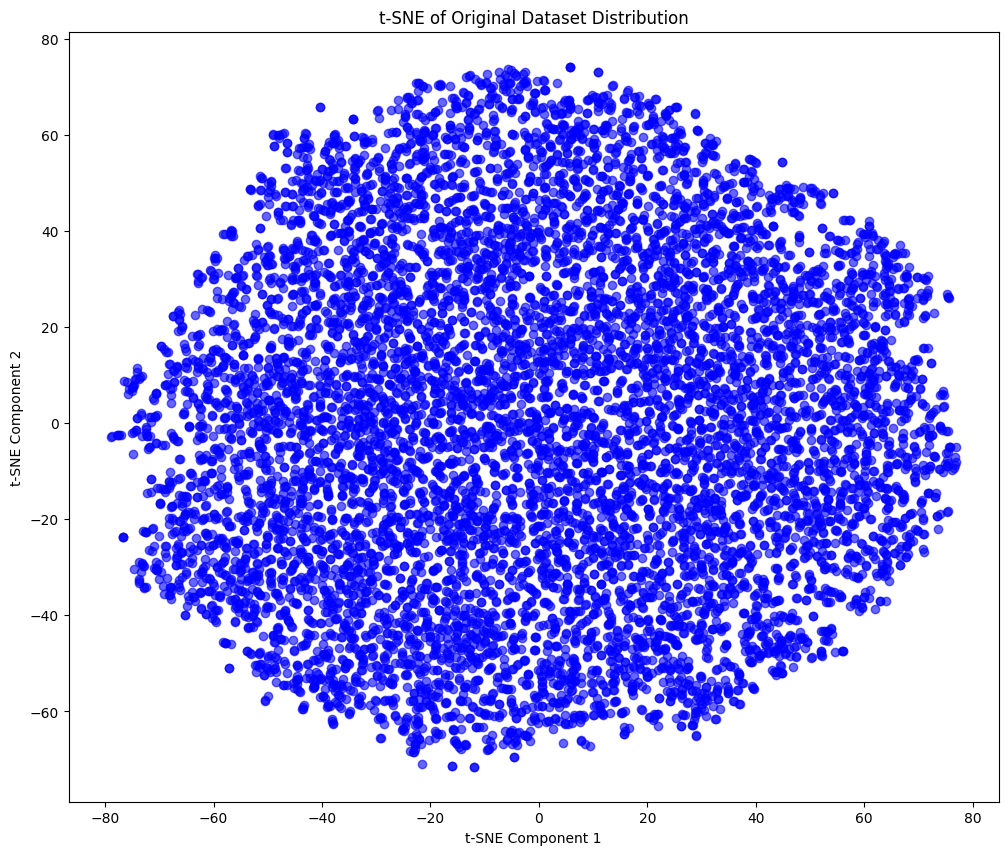

已保存原始数据集t-SNE可视化结果到: /data/qiaodan/code/diffmarl/plots/tsne/pp_original_dataset_original.png


In [43]:
downsample_dataset = plot_original_data_tsne(dataset_combined, save_dir, exp_id)


In [44]:
# Cell 4: 加载eval数据

step = 0

data_path = os.path.join(result_dir, f'eval_data_step_{step}.npz')
if not os.path.exists(data_path):
    print(f"错误：找不到时间步 {step} 的数据文件：{data_path}")
else:
    print(f"\n处理时间步 {step} 的数据...")
    states, actions = load_and_process_data(data_path)
    print(f"状态维度: {states.shape}, 动作维度: {actions.shape}")

eval_datasets = np.concatenate([states, actions], axis=1)
eval_datasets.shape


处理时间步 0 的数据...
状态维度: (250, 48), 动作维度: (250, 6)


(250, 54)

正在对eval数据进行t-SNE降维...


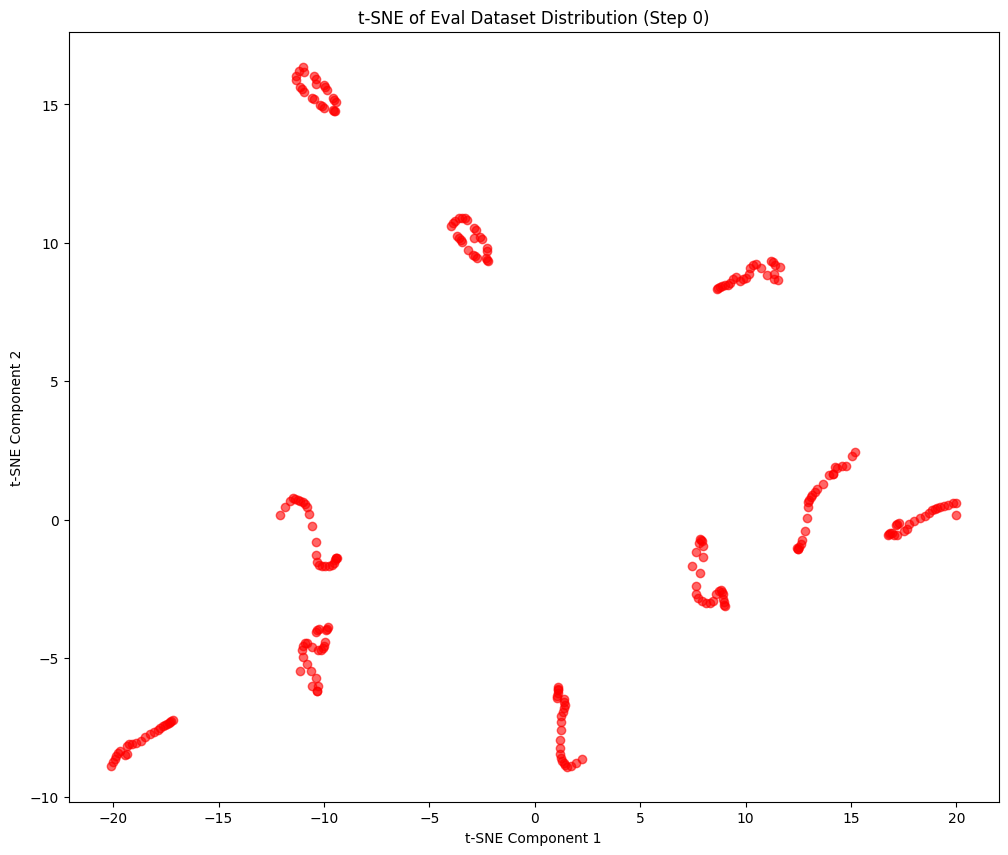

已保存eval数据集t-SNE可视化结果到: /data/qiaodan/code/diffmarl/plots/tsne/pp_eval_dataset_step_0_eval.png


In [45]:
plot_eval_data_tsne(eval_datasets, save_dir, exp_id, step)


正在对合并数据集进行t-SNE降维...


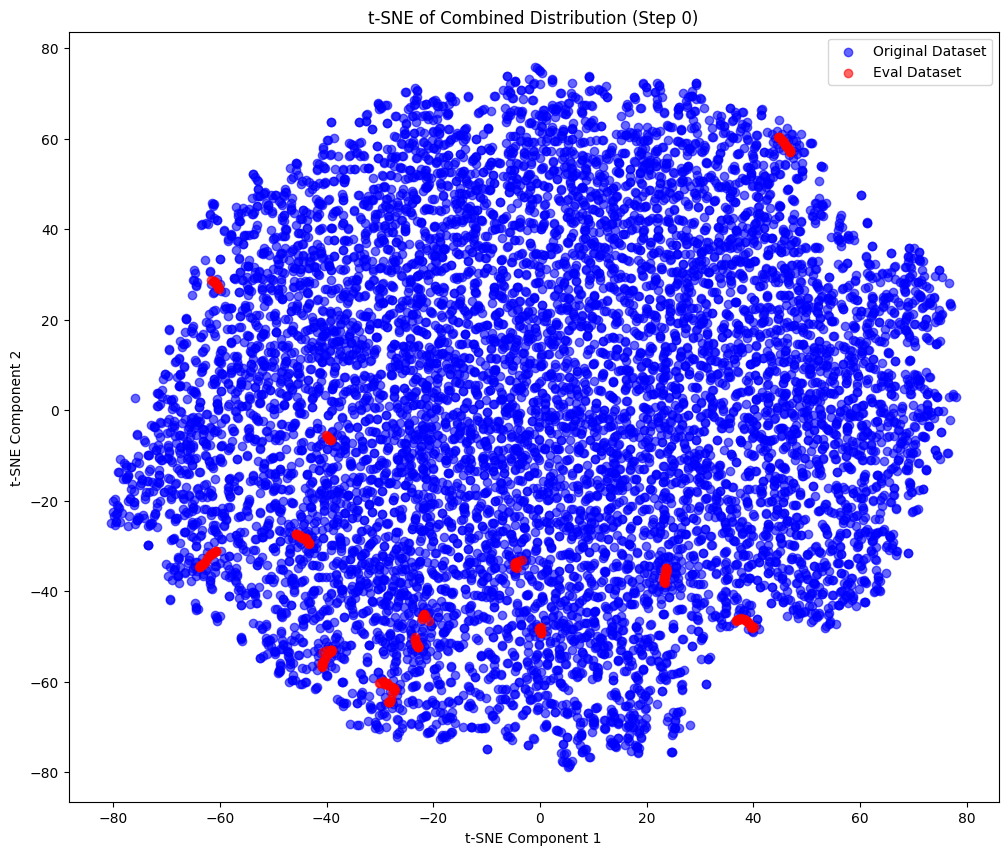

已保存合并数据集t-SNE可视化结果到: /data/qiaodan/code/diffmarl/plots/tsne/pp_combined_distribution_step_0_combined.png


In [46]:
plot_combined_tsne(downsample_dataset, eval_datasets, save_dir, exp_id, step)

In [47]:
# Cell 4: 加载eval数据

step = 100000

data_path = os.path.join(result_dir, f'eval_data_step_{step}.npz')
if not os.path.exists(data_path):
    print(f"错误：找不到时间步 {step} 的数据文件：{data_path}")
else:
    print(f"\n处理时间步 {step} 的数据...")
    states, actions = load_and_process_data(data_path)
    print(f"状态维度: {states.shape}, 动作维度: {actions.shape}")

eval_datasets = np.concatenate([states, actions], axis=1)
eval_datasets.shape


处理时间步 100000 的数据...
状态维度: (250, 48), 动作维度: (250, 6)


(250, 54)

正在对eval数据进行t-SNE降维...


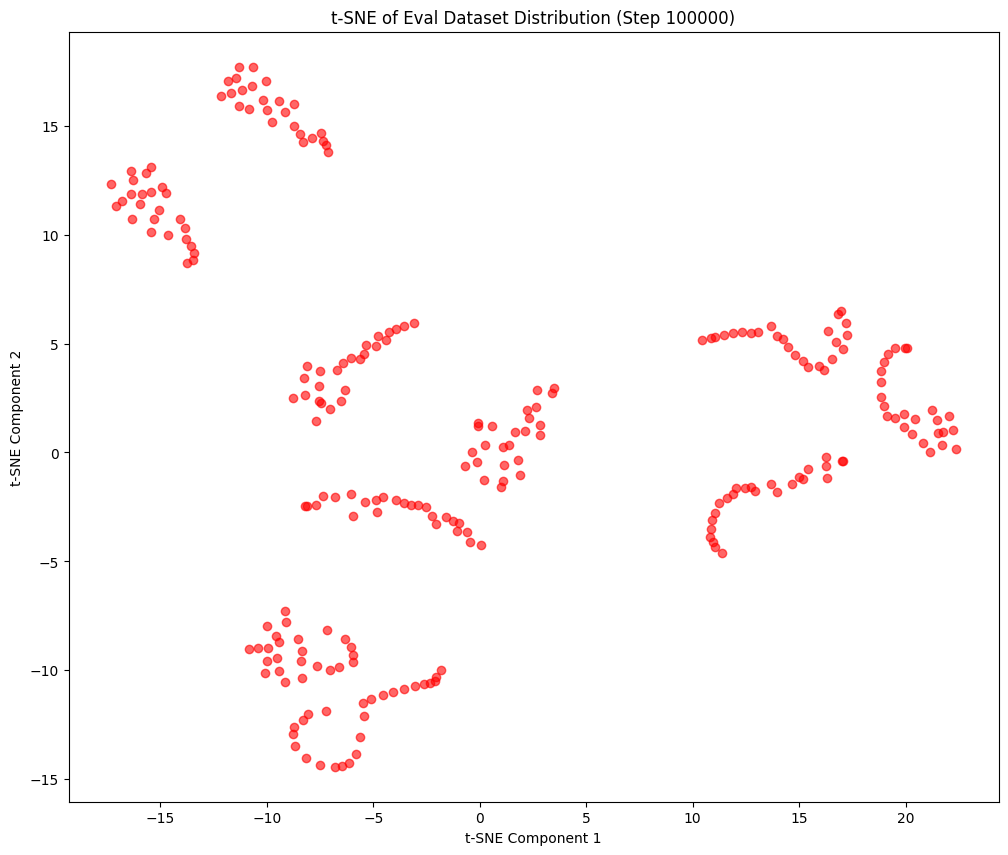

已保存eval数据集t-SNE可视化结果到: /data/qiaodan/code/diffmarl/plots/tsne/pp_eval_dataset_step_100000_eval.png


In [48]:
plot_eval_data_tsne(eval_datasets, save_dir, exp_id, step)


正在对合并数据集进行t-SNE降维...


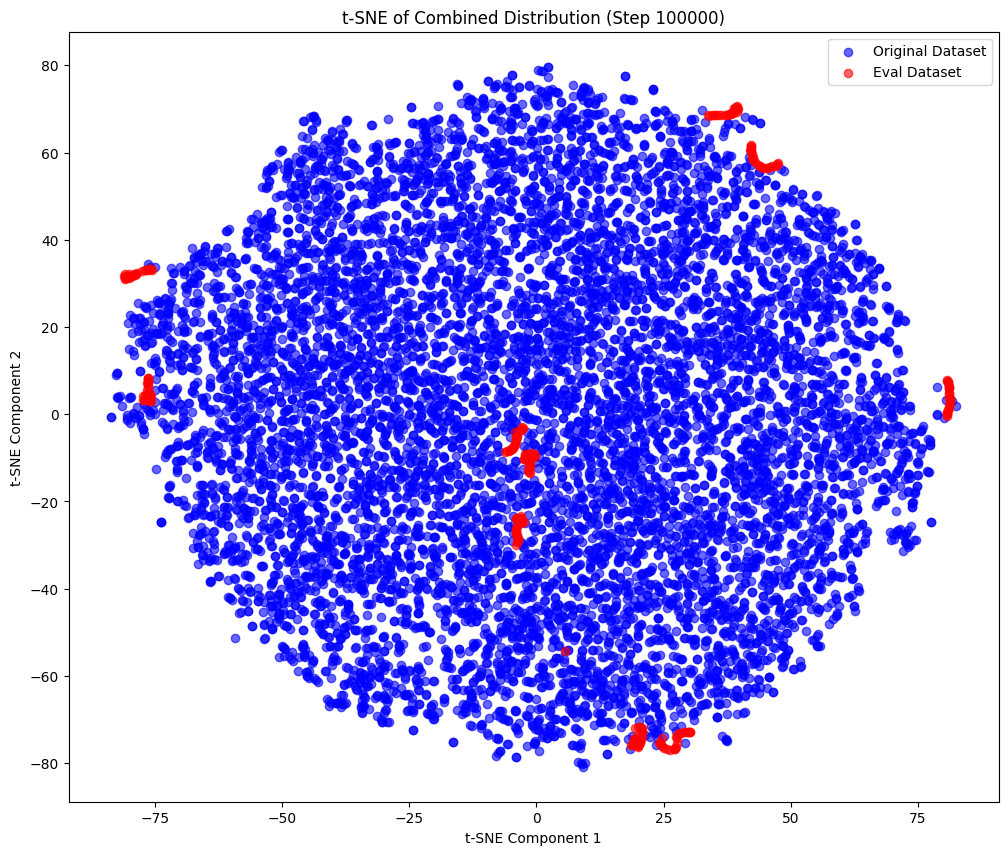

已保存合并数据集t-SNE可视化结果到: /data/qiaodan/code/diffmarl/plots/tsne/pp_combined_distribution_step_100000_combined.png


In [49]:
plot_combined_tsne(downsample_dataset, eval_datasets, save_dir, exp_id, step)